In [2]:
import math
import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt

### Real Data Analysis

In [3]:
def normality_tests(arr):
    '''Set of tests for normality distribution'''

    fig, ax = plt.subplots(1, 1, figsize=(6, 4))
    sm.qqplot(arr, line='s', ax=ax)
    plt.show()

    print('Skew of data set %14.3f' % scipy.stats.skew(arr))
    print('Skew test p-value %14.3f' % scipy.stats.skewtest(arr)[1])
    print('Kurt of data set %14.3f' % scipy.stats.kurtosis(arr))
    print('Kurt test p-value %14.3f' % scipy.stats.kurtosistest(arr)[1])
    print('Norm test p-value %14.3f' % scipy.stats.normaltest(arr)[1])

In [4]:
raw = pd.read_csv('~/quant_finance/python_for_finance/tr_eikon_eod_data.csv', index_col=0, parse_dates=True).dropna()
data = raw[['SPY', 'GLD', 'AAPL.O', 'MSFT.O']]
data.head()

,SPY,GLD,AAPL.O,MSFT.O
Date,,,,
2010-01-04,113.33,109.80,30.572827,30.950
2010-01-05,113.63,109.70,30.625684,30.960
2010-01-06,113.71,111.51,30.138541,30.770
2010-01-07,114.19,110.82,30.082827,30.452
2010-01-08,114.57,111.37,30.282827,30.660


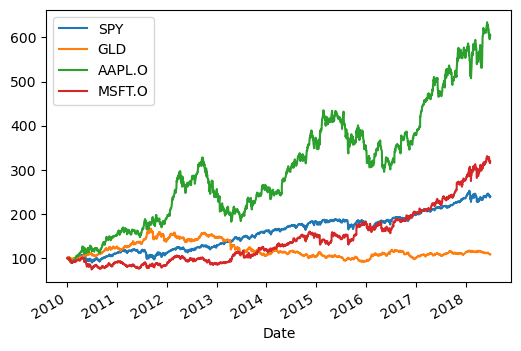

In [5]:
# Plot the time series, setting starting point @ 100
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
(data / data.iloc[0] * 100).plot(ax=ax)
plt.show()

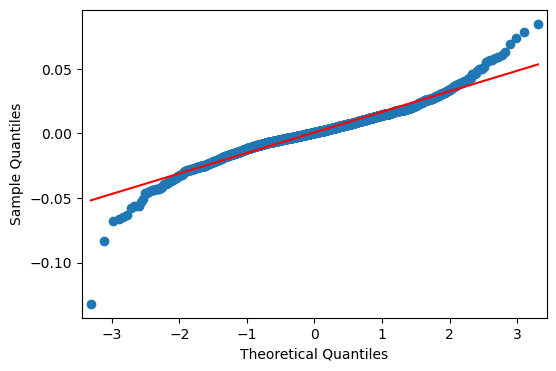

Skew of data set         -0.235
Skew test p-value          0.000
Kurt of data set          4.790
Kurt test p-value          0.000
Norm test p-value          0.000


In [6]:
# Daily log-returns
log_returns = np.log(data / data.shift(1))

normality_tests(log_returns['AAPL.O'].dropna())

Note the following: 

The p-values of the different tests are all very low, strongly rejecting the test hypothesis that the different sample data sets are normally distributed. This shows that the normal assumption for stock market returns and other asset classes, as embodied in the geometric Brownian motion model, cannot be justified in general and that one might have to use richer models that are able to generate fat tails (e.g., jump diffusion models or models with stochastic volatility)

array([[<Axes: title={'center': 'SPY'}>, <Axes: title={'center': 'GLD'}>],
       [<Axes: title={'center': 'AAPL.O'}>,
        <Axes: title={'center': 'MSFT.O'}>]], dtype=object)

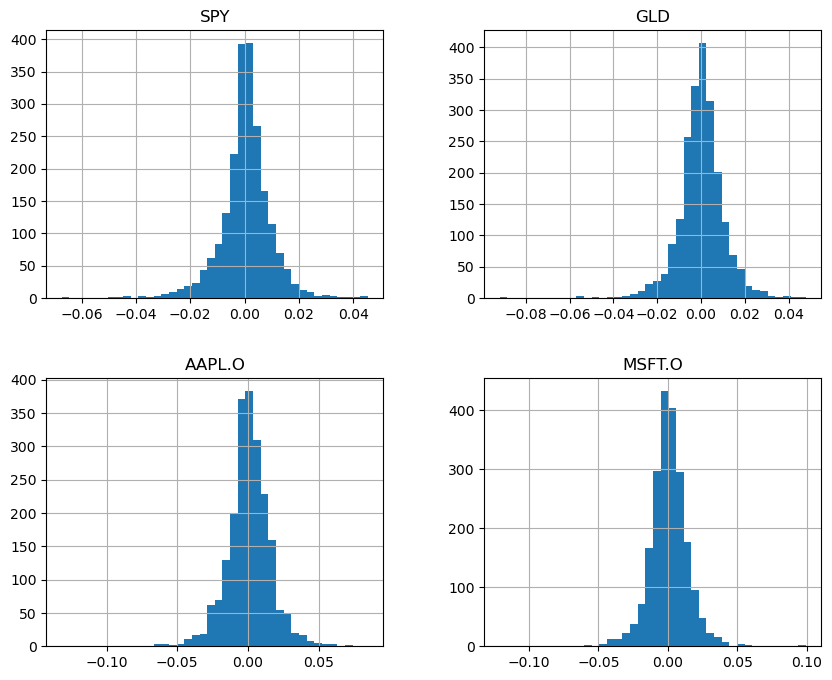

In [7]:
log_returns.hist(bins=40, figsize=(10, 8))

### Minimum Variance Portfolio
Assumptions: 
- Investors can only hold long positions (weights > 0, no shorting allowed)
- 100% of an inverstor's wealth is split among all positions

Essential ingredients:
- Expected portfolio return: $\mu_p = E\left[ \sum_j w_j k_j \right] = \sum_j w_j E\left[ k_j \right] = \sum_j w_j \mu_j = w^T \mu$
- Expected portfolio variance: $\sigma_{p}^2 = Var \left( \sum_j w_j k_j \right) = Cov \left( \sum_j w_j k_j, \sum_j w_j k_j \right) = \sum_{i,k = 1}^m w_i w_j \Sigma_{ij} = w^T \Sigma w$

In [8]:
nAssets = log_returns.shape[1]

# Generate random proportions for each asset with constraint of sum = 1
weights = np.random.uniform(0, 1, size=nAssets)
weights /= np.sum(weights)

# Consider the daily log-returns, we need to find the annualized log-returns
nTradingDays = 252
mean_log_returns = log_returns.mean(axis=0) * nTradingDays
cov_log_returns = log_returns.cov() * nTradingDays

# Expected portfolio return
mu = np.dot(mean_log_returns.to_numpy(), weights)

# Expected portfolio variance
var = weights.T @ cov_log_returns @ weights

# Expected portfolio volatility (standard deviation)
vol = np.sqrt(var)

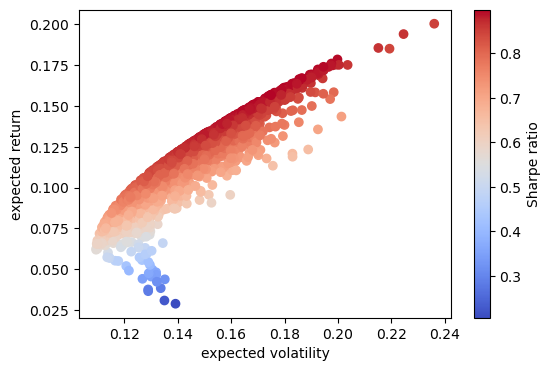

In [9]:
# Monte Carlo simulation of various weights (Markowitz bullet)
def port_return(w):
    return nTradingDays * log_returns.mean(axis=0) @ w

def port_volatility(w):
    return np.sqrt(w.T @ (log_returns.cov() * nTradingDays) @ w)

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm'
)
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
plt.show()

It is clear that not all weight distributions perform well when measured in terms of mean and volatility

For example, for a fixed risk level (expected volatility) of 15%, there are multiple portfolios that all show different returns. As an investor, one is generally interested in the maximum return given a fixed risk level or the minimum risk given a fixed return expectation. This set of portfolios then makes up the so-called efficient frontier

### Portfolio Optimization 
#### 1. Sharpe Ratio maximization

Maximization of Sharpe ratio
Optimal weights: [0.2545411  0.04228126 0.51191351 0.19126412]
Portfolio return with optimal weights: 0.1614313609112631
Portfolio volatility with optimal weights: 0.17983427137386732
Sharpe ratio with optimal weights: 0.8976673894135262


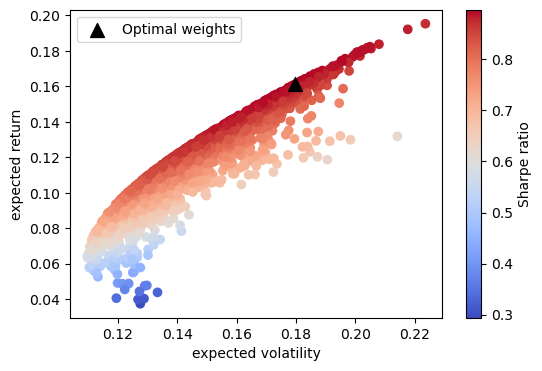

In [10]:
def neg_sharpe_ratio(w):
    '''Negative Sharpie ratio to be minimized'''
    port_return = w @ log_returns.mean(axis=0) * 252
    port_volatility = np.sqrt(w.T @ (log_returns.cov() * 252) @ w)
    sharpe_ratio = port_return / port_volatility # assuming no risk-free rate
    return -sharpe_ratio

constraints = ({'type': 'eq', # equality of constraint
                'fun': lambda x: np.sum(x) - 1}, # weights sum to 1
            )

results = scipy.optimize.minimize(
    fun=neg_sharpe_ratio, 
    x0=np.array([1 / nAssets] * nAssets),    # starting point at equal weights per asset
    method='SLSQP',                          # SLSQP allows bounds and constraints
    bounds=[(0, 1) for _ in range(nAssets)],
    constraints=constraints)

opt_weights = results['x']
opt_port_return = port_return(opt_weights)
opt_port_volatility = port_volatility(opt_weights)
opt_sharpe_ratio = opt_port_return / opt_port_volatility

print("Maximization of Sharpe ratio")
print(f"Optimal weights: {opt_weights}")
print(f"Portfolio return with optimal weights: {opt_port_return}")
print(f"Portfolio volatility with optimal weights: {opt_port_volatility}")
print(f"Sharpe ratio with optimal weights: {opt_sharpe_ratio}")

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)
ax.scatter(np.array(opt_port_volatility), np.array(opt_port_return), color='black', marker='^', s=100, label='Optimal weights')
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()

#### 2. Minimization of Portfolio Variance
This is the same as minimizing the expected portfolio volatility

Minimization of Portfolio Variance
Optimal weights: [5.43263078e-01 4.55675213e-01 1.03992764e-19 1.06170889e-03]
Portfolio return with optimal weights: 0.06022752282394161
Portfolio volatility with optimal weights: 0.10942155263422981
Sharpe ratio with optimal weights: 0.5504173663598786


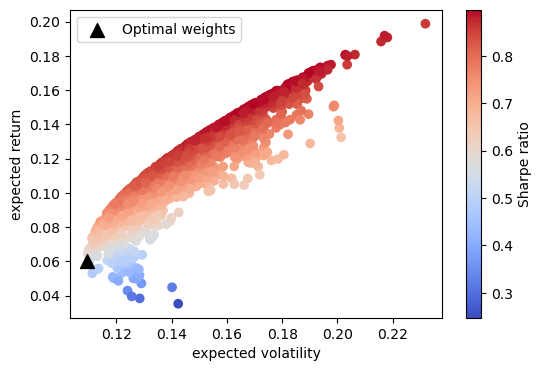

In [11]:
constraints = ({'type': 'eq',
                'fun': lambda x: np.sum(x) -1},
                )

results = scipy.optimize.minimize(
    fun=port_volatility,
    x0=np.array([1 / nAssets] * nAssets),
    method='SLSQP',
    bounds=[(0, 1) for _ in range(nAssets)],
    constraints=constraints,
)

opt_weights = results['x']
opt_port_return = port_return(opt_weights)
opt_port_volatility = port_volatility(opt_weights)
opt_sharpe_ratio = opt_port_return / opt_port_volatility

print("Minimization of Portfolio Variance")
print(f"Optimal weights: {opt_weights}")
print(f"Portfolio return with optimal weights: {opt_port_return}")
print(f"Portfolio volatility with optimal weights: {opt_port_volatility}")
print(f"Sharpe ratio with optimal weights: {opt_sharpe_ratio}")

prets = []
pvols = []
for p in range (2500):
    weights = np.random.random(nAssets)
    weights /= np.sum(weights)
    prets.append(port_return(weights))
    pvols.append(port_volatility(weights))
prets = np.array(prets)
pvols = np.array(pvols)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)
ax.scatter(np.array(opt_port_volatility), np.array(opt_port_return), color='black', marker='^', s=100, label='Optimal weights')
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()

### Efficient Frontier
The efficient frontier is a set of portfolios that present the lowest expected volatility given a pre-set expected return

The identification of such portfolios can be achieved by setting two constriants: 
1) Equality constraint for the portfolio return = target return
2) Equality constraint for the portfolio weights = 1

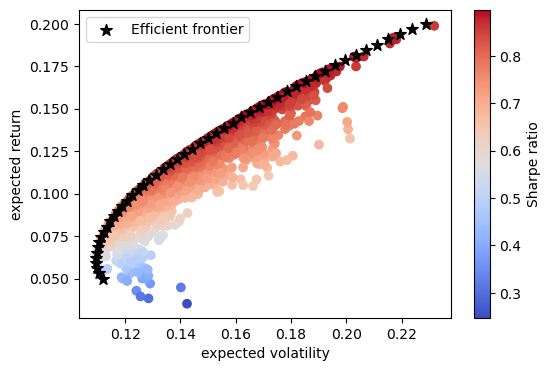

In [20]:
constraints = (
    {'type': 'eq', 'fun': lambda x: np.sum(x) - 1},
    {'type': 'eq', 'fun': lambda x: port_return(x) - target_return},
    )

bounds = [(0, 1) for _ in range(nAssets)]

target_returns = np.linspace(0.05, 0.2, 50)

efficient_front = []
for target_return in target_returns:
    results = scipy.optimize.minimize(
        fun=port_volatility,
        x0=[1 / nAssets] * nAssets,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
    )

    efficient_front.append((port_volatility(results['x']), target_return))
efficient_front = np.array(efficient_front)



fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)

ax.scatter(efficient_front[:, 0], efficient_front[:, 1], color='black', marker='*', s=75, label='Efficient frontier')

ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()

The efficient frontier is comprised of all optimal portfolios (achived by minimizing portfolio volatility/variance) with a set expected return

These portfolios dominate all other portfolios in terms of expected returns given a certain risk level

### Capital Market Line

We have optimized a portfolio according to a mixture of risky assets, consider now a risk-free asset which in practice could be a bond released by a major institution or a case account in a major bank

The addition of the risk-free asset in the portfolio can enhance the efficient investment opportunity for an investor

First determine an efficient portfolio of risky assets and then add the riskless asset to the mix

By adjusting the proportion of the investor’s wealth to be invested in the riskless asset it is possible to achieve any risk-return profile that lies on the straight line (in the risk-return space) between the riskless asset and the efficient portfolio.



Note the following conditions to find the Capital Market Line (CML):
1) The line has equation in the form: $A + B x$ where $x$ is the expected volatility

2) Obviously at $x=0$ we have the interest rate of the risk-free asset $A = r$
    - This means that $(0, r)$ is a point on the CML

3) The CML must touch the Efficient Frontier so we have 
    - $f(x) = r + Bx$
    - $f'(x) = B$

    Note that for a given volatility $\sigma_p$, $f(x)$ on the Efficient Frontier is equal to the expected return of the optimized portfolio with volatility $\sigma_p$. This means that
    $$\mu_p = r + B \sigma_p$$
    $$B = \frac{\mu_p - r}{\sigma_p}$$

    So the slope of the CML is the Sharpe ratio of the tangent portfolio

    
We need to solve a system of equations given the risk-free asset interest rate and the optimize portfolio values
$$
\begin{cases}
A - r = 0\\
f(\sigma^*) - r - B\sigma^* = 0 \\
f'(\sigma^*) - B = 0
\end{cases}
$$

In [24]:
# We need to use interpolation to extract an equation for the Efficient Frontier
sigma_front = efficient_front[:, 0]
mu_front = efficient_front[:, 1]

# sort by volatility, required for interpolation
idx = np.argsort(sigma_front)
sigma_front = sigma_front[idx]
mu_front = mu_front[idx]

# remove duplicate volatility values if present
sigma_unique, unique_idx = np.unique(sigma_front, return_index=True)
mu_unique = mu_front[unique_idx]

# smooth approximation of Efficient Frontier
frontier = scipy.interpolate.CubicSpline(sigma_unique, mu_unique)

# derivative of Efficient Frontier
frontier_derivative = frontier.derivative()



# Define risk-free rate
rf = 0.01


# Define constraints
def equations(p):
    """
    p[0] = A, intercept of CML
    p[1] = B, slope of CML
    p[2] = sigma_star, volatility of tangent portfolio
    """
    A, B, sigma_star = p

    eq1 = A - rf
    eq2 = A + B * sigma_star - frontier(sigma_star)
    eq3 = B - frontier_derivative(sigma_star)

    return np.array([eq1, eq2, eq3])

# Initial guess for A, B, and sigma_star
initial_guess = np.array([rf, 0.5, np.mean(sigma_unique)])

solution = scipy.optimize.root(equations, initial_guess)

if not solution.success:
    raise RuntimeError(solution.message)

A, B, sigma_star = solution.x
mu_star = frontier(sigma_star)

print("CML intercept:", A)
print("CML slope:", B)
print("Tangent portfolio volatility:", sigma_star)
print("Tangent portfolio expected return:", mu_star)
print("Sharpe ratio:", (mu_star - rf) / sigma_star)

CML intercept: 0.01
CML slope: 0.844709524091216
Tangent portfolio volatility: 0.19525391679751042
Tangent portfolio expected return: 0.17493284313479865
Sharpe ratio: 0.8447095240903337


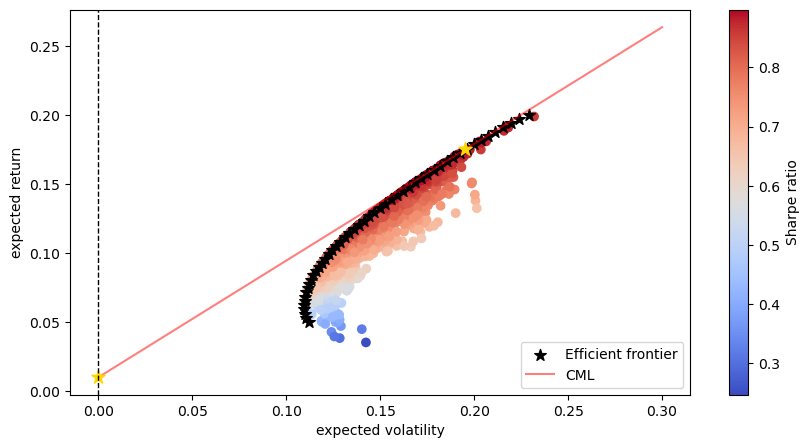

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
sc = ax.scatter(
    pvols,
    prets,
    c=prets / pvols,
    marker='o',
    cmap='coolwarm' 
)
ax.scatter(efficient_front[:, 0], efficient_front[:, 1], color='black', marker='*', s=75, label='Efficient frontier')

tangent_line = np.linspace(0, 0.3, 100)
ax.plot(tangent_line, [A + B * x for x in tangent_line], color='red', alpha=0.5, label='CML', zorder=1)

ax.scatter([0], [rf], color='gold', marker='*', s=100)
ax.scatter([sigma_star], [A + B * sigma_star], color='gold', marker='*', s=100)

ax.axvline(0, color='k', ls='--', lw=1)
ax.set_xlabel('expected volatility')
ax.set_ylabel('expected return')
cbar = fig.colorbar(sc, ax=ax)
cbar.set_label('Sharpe ratio')
ax.legend()
plt.show()

Given a risk-free asset return and an Efficient Frontier optimized for a set of risky assets, there exists only a unique portfolio on the Efficient Frontier that is tangent to the CML

This is the portfolio with the maximum Sharpe ratio

Investors then choose their mixing between risk-free and risky assets, moving themselves on the CML:

Examples: 
- 70% risk-free and 30% risky assets
- -20% risk-free (borrow) and 120% risky assets


Special case: 

Normally, the CML starts at: $(0,r_f)$ and slopes upward to touch the Efficient Frontier. But if $r_f$ is very high, the starting point moves upward on the vertical axis. The higher it moves, the flatter or more awkward the tangent becomes.

There is a region of the x-axis for which the tangent line touches the Markowitz bullet near the minimum-variance portfolio (left-most tip), this means that the risky assets are simply un-attractive due to the risk-free asset interet rate being so high and due to the idea of taking extra risks doesn't provide advantages in terms of expected return for the risky assets